conformal_llm_routing_v3_1.ipynb

# Proactive Conformal LLM Routing with Distribution-Free Safety Guarantees

**ACL SRW — Experiment Notebook v3.1**

Changes from v3:
- Per-dataset α: GSM8K uses α=0.30, MMLU uses α=0.20
- Added feasibility overview table: all 10 cheap models vs GPT-4 (population stats, no training)
- All cells use per-dataset ALPHA_PER_DS instead of global ALPHA
- Fixed evaluate_routing to take alpha as parameter

---

## Cell 0 — Installs & Imports

In [ ]:
!pip install -q datasets sentence-transformers scikit-learn matplotlib numpy scipy pandas

import numpy as np
import pandas as pd
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import beta as beta_dist
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


## Cell 1 — Configuration

In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================

DELTA = 0.10          # Confidence: guarantee holds with P >= 1 - DELTA

DATASETS = ['grade-school-math', 'mmlu']

# Per-dataset α: reflects realistic tolerance per application
# GSM8K (math): cheap model struggles more, allow higher violation budget
# MMLU (knowledge): moderate difficulty, standard budget
ALPHA_PER_DS = {
    'grade-school-math': 0.30,
    'mmlu': 0.20,
}

EMBEDDER_NAME = 'BAAI/bge-base-en-v1.5'

# 4-way split: train / cal / val / test
TRAIN_RATIO = 0.55
CAL_RATIO   = 0.15
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Gate cost is negligible vs LLM inference
COST_GATE = 0.0000

ROUTERBENCH_FILE = 'routerbench_0shot.pkl'

print(f'Config: δ={DELTA}')
print(f'Per-dataset α: {ALPHA_PER_DS}')
print(f'Split: train={TRAIN_RATIO}, cal={CAL_RATIO}, val={VAL_RATIO}, test={TEST_RATIO}')
print(f'Datasets: {DATASETS}')

Config: δ=0.1
Per-dataset α: {'grade-school-math': 0.3, 'mmlu': 0.2}
Split: train=0.55, cal=0.15, val=0.15, test=0.15
Datasets: ['grade-school-math', 'mmlu']


## Cell 2 — Load RouterBench

In [ ]:
if not os.path.exists(ROUTERBENCH_FILE):
    print('Downloading RouterBench 0-shot...')
    !pip install -q huggingface_hub
    from huggingface_hub import hf_hub_download
    hf_hub_download(
        repo_id='withmartian/routerbench',
        filename=ROUTERBENCH_FILE,
        repo_type='dataset',
        local_dir='.'
    )
    print('Download complete.')
else:
    print(f'{ROUTERBENCH_FILE} already present.')

with open(ROUTERBENCH_FILE, 'rb') as f:
    df = pickle.load(f)

print(f'Shape: {df.shape}')

pipe_cols = [c for c in df.columns if '|' in c]
non_pipe_cols = [c for c in df.columns if '|' not in c]

models_set = set()
fields_set = set()
for c in pipe_cols:
    parts = c.split('|')
    models_set.add(parts[0])
    if len(parts) > 1:
        fields_set.add(parts[1])

models_list = sorted(models_set)
print(f'Models ({len(models_list)}): {models_list}')
print(f'Fields per model: {sorted(fields_set)}')

DATASET_COL = 'eval_name'
PROMPT_COL = 'prompt'
print(f'\nAvailable datasets ({df[DATASET_COL].nunique()}):')
for name in sorted(df[DATASET_COL].unique()):
    print(f'  {name}: {(df[DATASET_COL] == name).sum()} rows')

routerbench_0shot.pkl:   0%|          | 0.00/99.6M [00:00<?, ?B/s]

Download complete.
Shape: (36497, 37)
Models (11): ['WizardLM/WizardLM-13B-V1.2', 'claude-instant-v1', 'claude-v1', 'claude-v2', 'gpt-3.5-turbo-1106', 'gpt-4-1106-preview', 'meta/code-llama-instruct-34b-chat', 'meta/llama-2-70b-chat', 'mistralai/mistral-7b-chat', 'mistralai/mixtral-8x7b-chat', 'zero-one-ai/Yi-34B-Chat']
Fields per model: ['model_response', 'total_cost']

Available datasets (86):
  Chinese_character_riddles: 100 rows
  abstract2title: 254 rows
  accounting_audit: 30 rows
  arc-challenge: 1470 rows
  bias_detection: 285 rows
  chinese-lantern-riddles: 20 rows
  chinese-remainder-theorem: 15 rows
  chinese_ancient_masterpieces_dynasty: 16 rows
  chinese_ancient_poetry: 25 rows
  chinese_chu_ci: 15 rows
  chinese_famous_novel: 20 rows
  chinese_hard_translations: 21 rows
  chinese_homonym: 21 rows
  chinese_idioms: 15 rows
  chinese_modern_poem_identification: 21 rows
  chinese_poem: 15 rows
  chinese_shi_jing: 34 rows
  chinese_song_ci: 16 rows
  chinese_tang_poetries: 37

## Cell 2b — Feasibility Overview: All Cheap Models vs GPT-4

Population-level statistics across all model pairs. No gate training — just π
and the theoretical feasibility constant C(π,α). This tells practitioners which
pairs are worth attempting before any model fitting.

In [ ]:
# ============================================================
# Cell 2b — Feasibility Overview: All Cheap Models vs GPT-4 (per dataset)
# ============================================================
# Population-level statistics per dataset. No gate training — just π
# and the theoretical feasibility constant C(π,α).

EXPENSIVE_MODEL = 'gpt-4-1106-preview'
exp_scores_all = pd.to_numeric(df[EXPENSIVE_MODEL], errors='coerce')

feasibility_rows = []

exp_cost_col_all = f'{EXPENSIVE_MODEL}|total_cost'
exp_cost_mean = pd.to_numeric(df[exp_cost_col_all], errors='coerce').dropna().mean()

print(f'{"Cheap Model":<30} {"Dataset":<15} {"α":>5} {"Cheap Acc":>9} {"π":>6} {"C(π,α)":>8} {"Φ*c":>6}')
print("-" * 83)

for ds_name in DATASETS:
    alpha_ds = ALPHA_PER_DS[ds_name]
    mask = df[DATASET_COL].str.lower().str.contains(ds_name.lower(), na=False)
    ds_df = df[mask]

    for model in sorted(models_list):
        if model == EXPENSIVE_MODEL:
            continue
        cheap_s = pd.to_numeric(ds_df[model], errors='coerce')
        exp_s = pd.to_numeric(ds_df[EXPENSIVE_MODEL], errors='coerce')
        valid = cheap_s.notna() & exp_s.notna()

        if valid.sum() == 0:
            continue

        cheap_bin = (cheap_s[valid] >= 0.5).astype(int)
        exp_bin = (exp_s[valid] >= 0.5).astype(int)

        cheap_acc = cheap_bin.mean()
        unsafe = ((1 - cheap_bin) * exp_bin).mean()
        pi = 1 - unsafe

        C = (1 - pi) * (1 - alpha_ds) / (pi * alpha_ds) if pi > 0 else float('inf')
        phi_c_star = (1 - 1 / (2 * C)) if C > 1 else 0.5

        cheap_cost_col_m = f'{model}|total_cost'
        if cheap_cost_col_m in ds_df.columns:
            cheap_cost_m = pd.to_numeric(ds_df[cheap_cost_col_m], errors='coerce').dropna().mean()
            cost_ratio = exp_cost_mean / max(cheap_cost_m, 1e-10)
        else:
            cost_ratio = float('nan')

        short_name = model.split('/')[-1]
        feasibility_rows.append({
            'model': model, 'short_name': short_name, 'dataset': ds_name,
            'alpha': alpha_ds, 'cheap_acc': cheap_acc,
            'pi': pi, 'C': C, 'phi_c_star': phi_c_star,
            'cost_ratio': cost_ratio
        })
        print(f'{short_name:<30} {ds_name:<15} {alpha_ds:>5.2f} {pi:>6.3f} {C:>8.3f} {phi_c_star:>6.3f} {cost_ratio:>9.1f}x')

print(f'\nNote: C < 1 means almost any gate works. C > 1 requires gate AUC > Φ*c.')

Cheap Model                    Dataset             α Cheap Acc      π   C(π,α)    Φ*c
-----------------------------------------------------------------------------------
WizardLM-13B-V1.2              grade-school-math  0.30  0.635    1.342  0.627      20.8x
claude-instant-v1              grade-school-math  0.30  0.836    0.458  0.500       5.6x
claude-v1                      grade-school-math  0.30  0.895    0.274  0.500       0.7x
claude-v2                      grade-school-math  0.30  0.931    0.172  0.500       0.5x
gpt-3.5-turbo-1106             grade-school-math  0.30  0.854    0.398  0.500       6.3x
code-llama-instruct-34b-chat   grade-school-math  0.30  0.514    2.208  0.774       9.8x
llama-2-70b-chat               grade-school-math  0.30  0.660    1.201  0.584       8.4x
mistral-7b-chat                grade-school-math  0.30  0.408    3.387  0.852      35.4x
mixtral-8x7b-chat              grade-school-math  0.30  0.646    1.279  0.609      12.4x
Yi-34B-Chat                  

## Cell 3 — Select Model Pair & Extract Data

In [ ]:
CHEAP_MODEL = 'mistralai/mixtral-8x7b-chat'
CHEAP_NAME = 'Mixtral-8x7B'
EXPENSIVE_NAME = 'GPT-4'

# Score columns = bare model name (RouterBench convention)
cheap_score_col = CHEAP_MODEL
exp_score_col = EXPENSIVE_MODEL

# Cost columns = model|total_cost
cheap_cost_col = f'{CHEAP_MODEL}|total_cost'
exp_cost_col = f'{EXPENSIVE_MODEL}|total_cost'

print('Column verification:')
print(f'  Cheap score:  "{cheap_score_col}" — exists: {cheap_score_col in df.columns}')
print(f'  Exp score:    "{exp_score_col}" — exists: {exp_score_col in df.columns}')
print(f'  Cheap cost:   "{cheap_cost_col}" — exists: {cheap_cost_col in df.columns}')
print(f'  Exp cost:     "{exp_cost_col}" — exists: {exp_cost_col in df.columns}')

# Extract costs from data
if cheap_cost_col in df.columns and exp_cost_col in df.columns:
    COST_CHEAP = pd.to_numeric(df[cheap_cost_col], errors='coerce').dropna().mean()
    COST_EXPENSIVE = pd.to_numeric(df[exp_cost_col], errors='coerce').dropna().mean()
    print(f'\nCosts: cheap=${COST_CHEAP:.6f}, expensive=${COST_EXPENSIVE:.6f}, ratio={COST_EXPENSIVE/max(COST_CHEAP,1e-10):.1f}x')
else:
    COST_CHEAP = 1.0
    COST_EXPENSIVE = 30.0
    print('Cost columns not found, using defaults.')

# ============================================================
# Extract data per dataset
# ============================================================

def binarize_scores(series):
    s = pd.to_numeric(series, errors='coerce')
    return (s >= 0.5).astype(int)

data_per_dataset = {}

for ds_name in DATASETS:
    print(f'\n=== {ds_name.upper()} ===')
    mask = df[DATASET_COL].str.lower().str.contains(ds_name.lower(), na=False)
    ds_df = df[mask].copy()
    print(f'  Rows matching: {len(ds_df)}')

    if len(ds_df) == 0:
        print(f'  ✗ No rows found.')
        continue

    cheap_raw = pd.to_numeric(ds_df[cheap_score_col], errors='coerce')
    exp_raw = pd.to_numeric(ds_df[exp_score_col], errors='coerce')
    valid_mask = cheap_raw.notna() & exp_raw.notna()
    ds_df = ds_df[valid_mask].copy()
    cheap_raw = cheap_raw[valid_mask]
    exp_raw = exp_raw[valid_mask]
    print(f'  Valid rows: {len(ds_df)}')

    if len(ds_df) == 0:
        continue

    cheap_correct = binarize_scores(cheap_raw)
    exp_correct = binarize_scores(exp_raw)

    # Safety label: Y=0 (unsafe) iff cheap wrong AND expensive correct
    Y = 1 - ((1 - cheap_correct) * exp_correct)
    Y = Y.astype(int)

    result_df = pd.DataFrame({
        'prompt': ds_df[PROMPT_COL].values,
        'cheap_correct': cheap_correct.values,
        'expensive_correct': exp_correct.values,
        'Y': Y.values,
    })

    pi = result_df['Y'].mean()
    alpha_ds = ALPHA_PER_DS[ds_name]
    print(f'  Cheap acc: {result_df["cheap_correct"].mean():.3f}, Exp acc: {result_df["expensive_correct"].mean():.3f}')
    print(f'  π = {pi:.3f}, α = {alpha_ds}')

    data_per_dataset[ds_name] = result_df

print(f'\nLoaded: {list(data_per_dataset.keys())}')

Column verification:
  Cheap score:  "mistralai/mixtral-8x7b-chat" — exists: True
  Exp score:    "gpt-4-1106-preview" — exists: True
  Cheap cost:   "mistralai/mixtral-8x7b-chat|total_cost" — exists: True
  Exp cost:     "gpt-4-1106-preview|total_cost" — exists: True

Costs: cheap=$0.000135, expensive=$0.003293, ratio=24.5x

=== GRADE-SCHOOL-MATH ===
  Rows matching: 7450
  Valid rows: 7450
  Cheap acc: 0.612, Exp acc: 0.956
  π = 0.646, α = 0.3

=== MMLU ===
  Rows matching: 14042
  Valid rows: 14042
  Cheap acc: 0.635, Exp acc: 0.812
  π = 0.784, α = 0.2

Loaded: ['grade-school-math', 'mmlu']


## Cell 4 — Embed Queries

In [ ]:
from sentence_transformers import SentenceTransformer

EMBEDDING_CACHE = 'embeddings_cache.pkl'

all_prompts = []
for ds_name, ds_df in data_per_dataset.items():
    all_prompts.extend(ds_df['prompt'].tolist())
unique_prompts = list(set(all_prompts))
print(f'Total unique prompts: {len(unique_prompts)}')

if os.path.exists(EMBEDDING_CACHE):
    print('Loading cached embeddings...')
    with open(EMBEDDING_CACHE, 'rb') as f:
        prompt_to_embedding = pickle.load(f)
    missing = [p for p in unique_prompts if p not in prompt_to_embedding]
    if not missing:
        print(f'  All {len(unique_prompts)} prompts cached.')
    else:
        print(f'  {len(missing)} new prompts to embed.')
else:
    prompt_to_embedding = {}
    missing = unique_prompts

if missing:
    print(f'Embedding {len(missing)} prompts with {EMBEDDER_NAME}...')
    embedder = SentenceTransformer(EMBEDDER_NAME)
    batch_size = 128
    for i in range(0, len(missing), batch_size):
        batch = missing[i:i+batch_size]
        embs = embedder.encode(batch, show_progress_bar=False, normalize_embeddings=True)
        for prompt, emb in zip(batch, embs):
            prompt_to_embedding[prompt] = emb
        if (i // batch_size) % 10 == 0:
            print(f'  Embedded {min(i+batch_size, len(missing))}/{len(missing)}')
    with open(EMBEDDING_CACHE, 'wb') as f:
        pickle.dump(prompt_to_embedding, f)
    print('Embeddings cached.')

# Attach embeddings
for ds_name, ds_df in data_per_dataset.items():
    emb_matrix = np.array([prompt_to_embedding[p] for p in ds_df['prompt']])
    data_per_dataset[ds_name] = (ds_df, emb_matrix)
    print(f'{ds_name}: embeddings shape = {emb_matrix.shape}')

Total unique prompts: 21487
Embedding 21487 prompts with BAAI/bge-base-en-v1.5...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Embedded 128/21487
  Embedded 1408/21487
  Embedded 2688/21487
  Embedded 3968/21487
  Embedded 5248/21487
  Embedded 6528/21487
  Embedded 7808/21487
  Embedded 9088/21487
  Embedded 10368/21487
  Embedded 11648/21487
  Embedded 12928/21487
  Embedded 14208/21487
  Embedded 15488/21487
  Embedded 16768/21487
  Embedded 18048/21487
  Embedded 19328/21487
  Embedded 20608/21487
Embeddings cached.
grade-school-math: embeddings shape = (7450, 768)
mmlu: embeddings shape = (14042, 768)


## Cell 5 — 4-Way Split: Train / Cal / Val / Test

**Critical**: Clean separation to avoid data leaks.
- Train: fit the gate
- Cal: conformal threshold selection (Clopper-Pearson)
- Val: val-tuned baseline picks its threshold here
- Test: final evaluation (run once for paper numbers)

In [ ]:
splits_per_dataset = {}

for ds_name, (ds_df, emb_matrix) in data_per_dataset.items():
    Y = ds_df['Y'].values
    n = len(Y)

    # First split: train vs rest
    rest_ratio = CAL_RATIO + VAL_RATIO + TEST_RATIO
    idx_train, idx_rest = train_test_split(
        np.arange(n), test_size=rest_ratio, random_state=SEED, stratify=Y
    )

    # Second split: cal vs val+test
    Y_rest = Y[idx_rest]
    cal_frac = CAL_RATIO / rest_ratio
    idx_cal, idx_valtest = train_test_split(
        idx_rest, test_size=(1 - cal_frac), random_state=SEED, stratify=Y_rest
    )

    # Third split: val vs test
    Y_valtest = Y[idx_valtest]
    val_frac = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    idx_val, idx_test = train_test_split(
        idx_valtest, test_size=(1 - val_frac), random_state=SEED, stratify=Y_valtest
    )

    splits_per_dataset[ds_name] = {
        'X_train': emb_matrix[idx_train], 'Y_train': Y[idx_train],
        'X_cal':   emb_matrix[idx_cal],   'Y_cal':   Y[idx_cal],
        'X_val':   emb_matrix[idx_val],   'Y_val':   Y[idx_val],
        'X_test':  emb_matrix[idx_test],  'Y_test':  Y[idx_test],
    }

    print(f'{ds_name}: '
          f'Train={len(idx_train)} (π={Y[idx_train].mean():.3f}), '
          f'Cal={len(idx_cal)} (π={Y[idx_cal].mean():.3f}), '
          f'Val={len(idx_val)} (π={Y[idx_val].mean():.3f}), '
          f'Test={len(idx_test)} (π={Y[idx_test].mean():.3f})')

grade-school-math: Train=4097 (π=0.646), Cal=1117 (π=0.646), Val=1118 (π=0.646), Test=1118 (π=0.646)
mmlu: Train=7723 (π=0.784), Cal=2106 (π=0.784), Val=2106 (π=0.784), Test=2107 (π=0.784)


## Cell 6 — Utilities

In [ ]:
def ucb_clopper_pearson(k, n, delta):
    # Clopper-Pearson upper confidence bound on binomial proportion.
    if n == 0: return 1.0
    if k == n: return 1.0
    return beta_dist.ppf(1 - delta, k + 1, n - k)

def find_conformal_threshold(scores, labels, alpha, delta):
    # Find lowest t s.t. CP-UCB on unsafe fraction among routed (score >= t) is <= alpha.
    unique_thresholds = np.sort(np.unique(scores))
    best_t = np.inf
    info = {'thresholds_checked': len(unique_thresholds), 'feasible': False}
    for t in unique_thresholds:
        routed_mask = scores >= t
        n_routed = routed_mask.sum()
        if n_routed == 0: continue
        k_unsafe = ((routed_mask) & (labels == 0)).sum()
        ucb = ucb_clopper_pearson(k_unsafe, n_routed, delta)
        if ucb <= alpha:
            info.update({'feasible': True, 't_star': t,
                         'n_routed_cal': int(n_routed),
                         'k_unsafe_cal': int(k_unsafe), 'ucb': ucb})
            return t, info
    return best_t, info

def find_val_tuned_threshold(scores, labels, alpha):
    # Find lowest t on validation set s.t. empirical violation <= alpha.
    # This is the 'careful practitioner' baseline -- no formal guarantee.
    unique_thresholds = np.sort(np.unique(scores))
    best_t = np.inf
    info = {'feasible': False}
    for t in unique_thresholds:
        routed_mask = scores >= t
        n_routed = routed_mask.sum()
        if n_routed == 0: continue
        k_unsafe = ((routed_mask) & (labels == 0)).sum()
        empirical_viol = k_unsafe / n_routed
        if empirical_viol <= alpha:
            info.update({'feasible': True, 't_val': t,
                         'n_routed_val': int(n_routed),
                         'empirical_viol': empirical_viol})
            return t, info
    return best_t, info

def compute_feasibility(pi, alpha):
    if pi == 0 or alpha == 0: return np.inf, 1.0, 1.0
    C = (1 - pi) * (1 - alpha) / (pi * alpha)
    phi_c = min(1.0, C / 2)
    phi_c_star = (1 - 1 / (2 * C)) if C > 1 else 0.5
    return C, phi_c, phi_c_star

def evaluate_routing(scores, labels, threshold, alpha):
    # alpha passed explicitly — no global dependency
    routed = scores >= threshold
    n_total = len(scores)
    n_routed = routed.sum()
    coverage = n_routed / n_total if n_total > 0 else 0
    if n_routed == 0:
        return {'coverage': 0.0, 'violation': 0.0, 'n_routed': 0,
                'n_total': n_total, 'n_unsafe_routed': 0, 'guarantee_holds': True}
    n_unsafe_routed = ((routed) & (labels == 0)).sum()
    violation = n_unsafe_routed / n_routed
    return {'coverage': coverage, 'violation': violation,
            'n_routed': int(n_routed), 'n_total': n_total,
            'n_unsafe_routed': int(n_unsafe_routed),
            'guarantee_holds': violation <= alpha}

def compute_cost(coverage, cost_cheap=None, cost_expensive=None):
    if cost_cheap is None: cost_cheap = COST_CHEAP
    if cost_expensive is None: cost_expensive = COST_EXPENSIVE
    return COST_GATE + coverage * cost_cheap + (1 - coverage) * cost_expensive

print('Utilities defined.')
print(f'UCB(0, 300, 0.10) = {ucb_clopper_pearson(0, 300, 0.10):.4f}')

Utilities defined.
UCB(0, 300, 0.10) = 0.0076


## Cell 7 — Train Gate & Feasibility Analysis

In [ ]:
gates = {}
for ds_name, splits in splits_per_dataset.items():
    alpha_ds = ALPHA_PER_DS[ds_name]
    print(f'\n=== {ds_name.upper()} (α={alpha_ds}) ===')

    # Feasibility check
    pi = splits['Y_cal'].mean()
    C, phi_c, phi_c_star = compute_feasibility(pi, alpha_ds)
    print(f'  π={pi:.3f}, C={C:.3f}, Φc={phi_c:.3f}, Φ*c={phi_c_star:.3f}')

    # Train gate on train set only
    gate = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=SEED)
    gate.fit(splits['X_train'], splits['Y_train'])

    # Score all splits
    cal_scores  = gate.predict_proba(splits['X_cal'])[:, 1]
    val_scores  = gate.predict_proba(splits['X_val'])[:, 1]
    test_scores = gate.predict_proba(splits['X_test'])[:, 1]

    auc_cal  = roc_auc_score(splits['Y_cal'],  cal_scores)  if len(np.unique(splits['Y_cal']))  > 1 else 0.5
    auc_val  = roc_auc_score(splits['Y_val'],  val_scores)  if len(np.unique(splits['Y_val']))  > 1 else 0.5
    auc_test = roc_auc_score(splits['Y_test'], test_scores) if len(np.unique(splits['Y_test'])) > 1 else 0.5

    print(f'  AUC: cal={auc_cal:.3f}, val={auc_val:.3f}, test={auc_test:.3f}')

    if auc_cal >= phi_c:
        print(f'  ✓ Feasibility guaranteed (Theorem 1)')
    elif auc_cal >= phi_c_star:
        print(f'  ✓ Feasibility guaranteed (Theorem 2)')
    else:
        print(f'  ⚠ Below Φ*c — may still work via local ROC structure')

    gates[ds_name] = {
        'gate': gate, 'alpha': alpha_ds,
        'cal_scores': cal_scores, 'val_scores': val_scores, 'test_scores': test_scores,
        'auc_cal': auc_cal, 'auc_val': auc_val, 'auc_test': auc_test,
        'pi': pi, 'C': C, 'phi_c': phi_c, 'phi_c_star': phi_c_star,
    }


=== GRADE-SCHOOL-MATH (α=0.3) ===
  π=0.646, C=1.277, Φc=0.638, Φ*c=0.608
  AUC: cal=0.581, val=0.593, test=0.578
  ⚠ Below Φ*c — may still work via local ROC structure

=== MMLU (α=0.2) ===
  π=0.784, C=1.102, Φc=0.551, Φ*c=0.546
  AUC: cal=0.675, val=0.657, test=0.678
  ✓ Feasibility guaranteed (Theorem 1)


## Cell 8 — Conformal Threshold (on Cal set)

In [ ]:
conformal_results = {}
for ds_name, splits in splits_per_dataset.items():
    alpha_ds = ALPHA_PER_DS[ds_name]
    print(f'\n=== {ds_name.upper()} (α={alpha_ds}) ===')
    g = gates[ds_name]

    # Conformal uses CAL set
    t_star, cal_info = find_conformal_threshold(g['cal_scores'], splits['Y_cal'], alpha_ds, DELTA)
    test_result = evaluate_routing(g['test_scores'], splits['Y_test'], t_star, alpha_ds)

    print(f'  t*={t_star:.4f}, feasible={cal_info["feasible"]}')
    if cal_info['feasible']:
        print(f'  Cal: {cal_info["n_routed_cal"]} routed, {cal_info["k_unsafe_cal"]} unsafe, UCB={cal_info["ucb"]:.4f}')
    print(f'  Test: cov={test_result["coverage"]:.3f}, viol={test_result["violation"]:.3f}, holds={test_result["guarantee_holds"]}')

    conformal_results[ds_name] = {'t_star': t_star, 'cal_info': cal_info, 'test_result': test_result}


=== GRADE-SCHOOL-MATH (α=0.3) ===
  t*=0.6513, feasible=True
  Cal: 391 routed, 105 unsafe, UCB=0.2994
  Test: cov=0.367, viol=0.280, holds=True

=== MMLU (α=0.2) ===
  t*=0.6095, feasible=True
  Cal: 1896 routed, 356 unsafe, UCB=0.1998
  Test: cov=0.903, viol=0.191, holds=True


## Cell 9 — Val-Tuned Baseline (on Val set)

The "careful practitioner" baseline: pick the lowest threshold on the validation set
such that the empirical violation rate is ≤ α. No formal guarantee — just empirical tuning.

In [ ]:
val_tuned_results = {}
for ds_name, splits in splits_per_dataset.items():
    alpha_ds = ALPHA_PER_DS[ds_name]
    print(f'\n=== {ds_name.upper()} (α={alpha_ds}) ===')
    g = gates[ds_name]

    # Val-tuned uses VAL set (separate from cal!)
    t_val, val_info = find_val_tuned_threshold(g['val_scores'], splits['Y_val'], alpha_ds)
    test_result = evaluate_routing(g['test_scores'], splits['Y_test'], t_val, alpha_ds)

    print(f'  t_val={t_val:.4f}, feasible={val_info["feasible"]}')
    if val_info['feasible']:
        print(f'  Val: {val_info["n_routed_val"]} routed, empirical_viol={val_info["empirical_viol"]:.4f}')
    print(f'  Test: cov={test_result["coverage"]:.3f}, viol={test_result["violation"]:.3f}, holds={test_result["guarantee_holds"]}')

    val_tuned_results[ds_name] = {'t_val': t_val, 'val_info': val_info, 'test_result': test_result}


=== GRADE-SCHOOL-MATH (α=0.3) ===
  t_val=0.6440, feasible=True
  Val: 682 routed, empirical_viol=0.2991
  Test: cov=0.596, viol=0.317, holds=False

=== MMLU (α=0.2) ===
  t_val=0.5771, feasible=True
  Val: 1946 routed, empirical_viol=0.1999
  Test: cov=0.926, viol=0.196, holds=True


## Cell 10 — Trivial Baselines

In [ ]:
baseline_results = {}
for ds_name, splits in splits_per_dataset.items():
    alpha_ds = ALPHA_PER_DS[ds_name]
    print(f'\n=== {ds_name.upper()} (α={alpha_ds}) ===')
    Y_test = splits['Y_test']
    g = gates[ds_name]
    n = len(Y_test)
    pi_test = Y_test.mean()

    baselines = {}
    baselines['Always-Cheap']     = {'coverage': 1.0,      'violation': 1 - pi_test, 'guarantee_holds': (1 - pi_test) <= alpha_ds}
    baselines['Always-Expensive'] = {'coverage': 0.0,      'violation': 0.0,         'guarantee_holds': True}
    baselines['Oracle']           = {'coverage': pi_test,   'violation': 0.0,         'guarantee_holds': True}
    baselines['Naive (t=0.5)']    = evaluate_routing(g['test_scores'], Y_test, 0.5, alpha_ds)

    # Random baseline matched to conformal coverage
    conf_cov = conformal_results[ds_name]['test_result']['coverage']
    n_to_route = int(conf_cov * n)
    if n_to_route > 0:
        rng = np.random.RandomState(SEED)
        random_viols = []
        for _ in range(1000):
            idx = rng.choice(n, n_to_route, replace=False)
            random_viols.append((Y_test[idx] == 0).mean())
        baselines['Random (matched)'] = {
            'coverage': conf_cov, 'violation': np.mean(random_viols),
            'violation_std': np.std(random_viols), 'guarantee_holds': np.mean(random_viols) <= alpha_ds
        }
    else:
        baselines['Random (matched)'] = {'coverage': 0.0, 'violation': 0.0, 'guarantee_holds': True}

    baseline_results[ds_name] = baselines
    for name, res in baselines.items():
        v = f'{res["violation"]:.3f}'
        if 'violation_std' in res: v += f' ± {res["violation_std"]:.3f}'
        print(f'  {name:25s} cov={res["coverage"]:.3f}  viol={v}  holds={res["guarantee_holds"]}')


=== GRADE-SCHOOL-MATH (α=0.3) ===
  Always-Cheap              cov=1.000  viol=0.354  holds=False
  Always-Expensive          cov=0.000  viol=0.000  holds=True
  Oracle                    cov=0.646  viol=0.000  holds=True
  Naive (t=0.5)             cov=1.000  viol=0.354  holds=False
  Random (matched)          cov=0.367  viol=0.354 ± 0.020  holds=False

=== MMLU (α=0.2) ===
  Always-Cheap              cov=1.000  viol=0.216  holds=False
  Always-Expensive          cov=0.000  viol=0.000  holds=True
  Oracle                    cov=0.784  viol=0.000  holds=True
  Naive (t=0.5)             cov=0.993  viol=0.215  holds=False
  Random (matched)          cov=0.903  viol=0.216 ± 0.003  holds=False


## Cell 11 — Results Summary Table

In [ ]:
for ds_name in DATASETS:
    if ds_name not in conformal_results: continue
    g = gates[ds_name]
    alpha_ds = ALPHA_PER_DS[ds_name]
    cr = conformal_results[ds_name]
    vt = val_tuned_results[ds_name]
    bl = baseline_results[ds_name]

    print(f'\n{"="*85}')
    print(f'  {ds_name.upper()} — {CHEAP_NAME} vs {EXPENSIVE_NAME} | π={g["pi"]:.3f}, AUC={g["auc_test"]:.3f}, α={alpha_ds}')
    print(f'{"="*85}')
    print(f'{"Method":30s} {"Coverage":>10s} {"Violation":>10s} {"Cost":>12s} {"Savings":>8s} {"≤α?":>5s}')
    print(f'{"-"*30} {"-"*10} {"-"*10} {"-"*12} {"-"*8} {"-"*5}')

    rows = [
        ('Conformal (ours)',   cr['test_result']['coverage'], cr['test_result']['violation'],
         compute_cost(cr['test_result']['coverage']), cr['test_result']['guarantee_holds']),
        ('Val-Tuned',          vt['test_result']['coverage'], vt['test_result']['violation'],
         compute_cost(vt['test_result']['coverage']), vt['test_result']['violation'] <= alpha_ds),
        ('Naive (t=0.5)',      bl['Naive (t=0.5)']['coverage'], bl['Naive (t=0.5)']['violation'],
         compute_cost(bl['Naive (t=0.5)']['coverage']), bl['Naive (t=0.5)']['violation'] <= alpha_ds),
        ('Random (matched)',   bl['Random (matched)']['coverage'], bl['Random (matched)']['violation'],
         compute_cost(bl['Random (matched)']['coverage']), bl['Random (matched)']['guarantee_holds']),
        ('Oracle',             bl['Oracle']['coverage'], 0.0,
         compute_cost(bl['Oracle']['coverage']), True),
        ('Always-Cheap',       1.0, bl['Always-Cheap']['violation'],
         COST_CHEAP + COST_GATE, bl['Always-Cheap']['guarantee_holds']),
        ('Always-Expensive',   0.0, 0.0, COST_EXPENSIVE, True),
    ]
    for name, cov, viol, cost, holds in rows:
        savings = (1 - cost / COST_EXPENSIVE) * 100
        print(f'{name:30s} {cov:10.3f} {viol:10.3f} {cost:12.6f} {savings:7.1f}% {"✓" if holds else "✗":>5s}')


  GRADE-SCHOOL-MATH — Mixtral-8x7B vs GPT-4 | π=0.646, AUC=0.578, α=0.3
Method                           Coverage  Violation         Cost  Savings   ≤α?
------------------------------ ---------- ---------- ------------ -------- -----
Conformal (ours)                    0.367      0.280     0.002135    35.2%     ✓
Val-Tuned                           0.596      0.317     0.001411    57.1%     ✗
Naive (t=0.5)                       1.000      0.354     0.000135    95.9%     ✗
Random (matched)                    0.367      0.354     0.002135    35.2%     ✗
Oracle                              0.646      0.000     0.001253    61.9%     ✓
Always-Cheap                        1.000      0.354     0.000135    95.9%     ✗
Always-Expensive                    0.000      0.000     0.003293     0.0%     ✓

  MMLU — Mixtral-8x7B vs GPT-4 | π=0.784, AUC=0.678, α=0.2
Method                           Coverage  Violation         Cost  Savings   ≤α?
------------------------------ ---------- ---------- ----

## Cell 12 — α-Sweep: Guarantee Reliability (KEY FIGURE)

This is the most important figure in the paper. It sweeps α from 0.05 to 0.80 and shows:
- Conformal: realized violation is ALWAYS ≤ α (below the diagonal)
- Val-tuned: sometimes violates (above the diagonal)
- Naive: uncontrolled violation

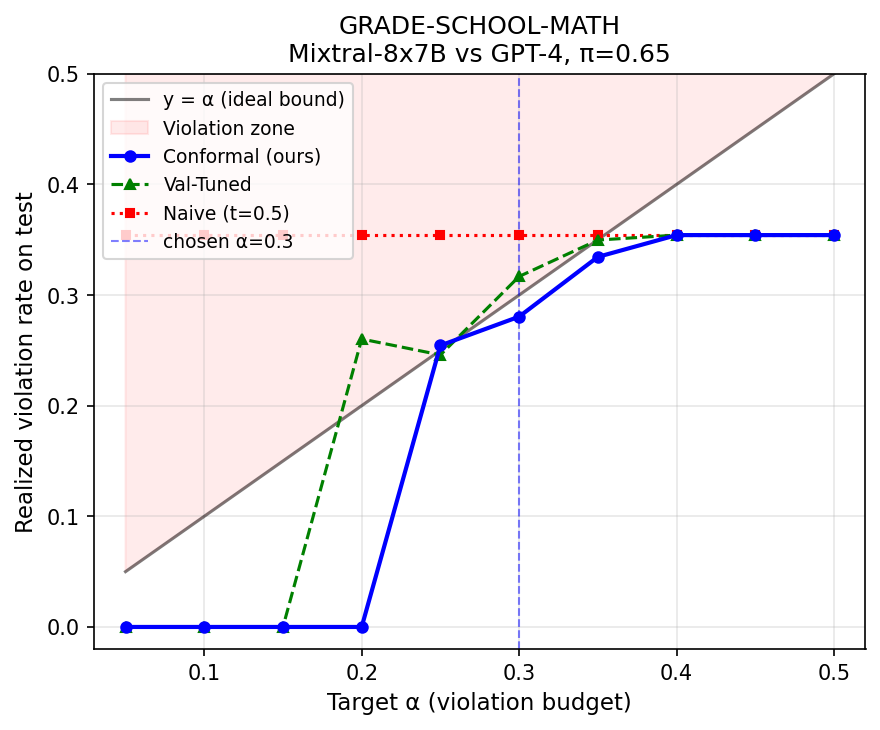

Saved: fig_alpha_sweep_grade-school-math.pdf


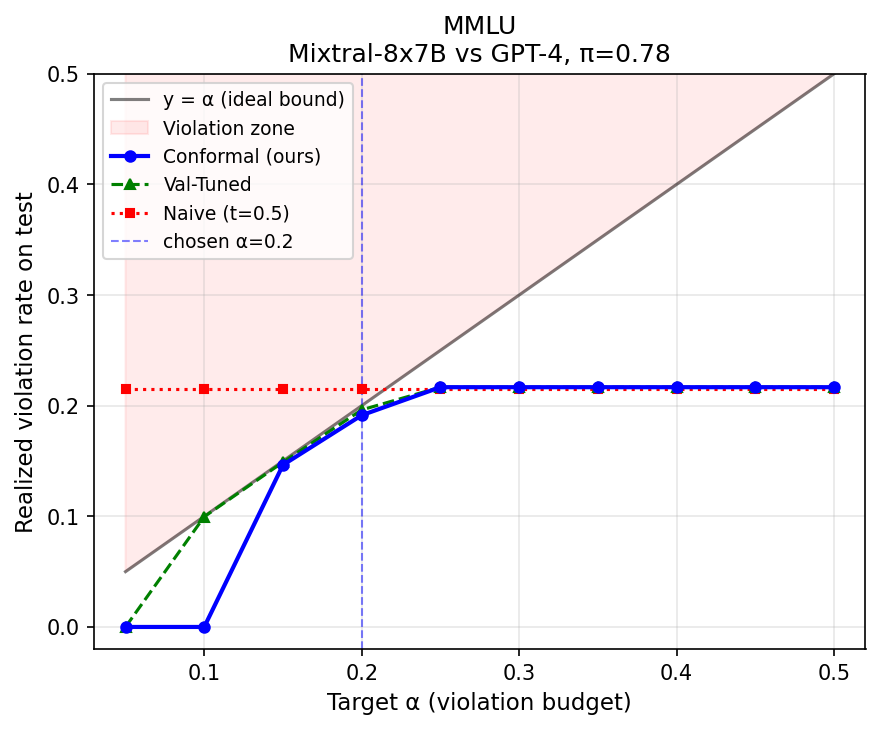

Saved: fig_alpha_sweep_mmlu.pdf


In [ ]:
alpha_values = np.arange(0.05, 0.55, 0.05)

active_ds = [d for d in DATASETS if d in conformal_results]
n_ds = len(active_ds)

for ds_name in active_ds:
    fig, ax = plt.subplots(figsize=(6, 5))
    g = gates[ds_name]
    alpha_ds = ALPHA_PER_DS[ds_name]
    Y_cal  = splits_per_dataset[ds_name]['Y_cal']
    Y_val  = splits_per_dataset[ds_name]['Y_val']
    Y_test = splits_per_dataset[ds_name]['Y_test']

    conformal_viols = []
    val_tuned_viols = []
    naive_viols = []

    for a in alpha_values:
        t_conf, _ = find_conformal_threshold(g['cal_scores'], Y_cal, a, DELTA)
        res_conf = evaluate_routing(g['test_scores'], Y_test, t_conf, a)
        conformal_viols.append(res_conf['violation'])

        t_val, _ = find_val_tuned_threshold(g['val_scores'], Y_val, a)
        res_val = evaluate_routing(g['test_scores'], Y_test, t_val, a)
        val_tuned_viols.append(res_val['violation'])

        res_naive = evaluate_routing(g['test_scores'], Y_test, 0.5, a)
        naive_viols.append(res_naive['violation'])

    ax.plot(alpha_values, alpha_values, 'k-', lw=1.5, alpha=0.5, label='y = α (ideal bound)')
    ax.fill_between(alpha_values, alpha_values, 1.0, alpha=0.08, color='red', label='Violation zone')
    ax.plot(alpha_values, conformal_viols, 'b-o', ms=5, lw=2, label='Conformal (ours)', zorder=5)
    ax.plot(alpha_values, val_tuned_viols, 'g--^', ms=5, lw=1.5, label='Val-Tuned', zorder=4)
    ax.plot(alpha_values, naive_viols, 'r:s', ms=4, lw=1.5, label='Naive (t=0.5)', zorder=3)
    ax.axvline(x=alpha_ds, color='blue', ls='--', lw=1, alpha=0.5, label=f'chosen α={alpha_ds}')

    ax.set_xlabel('Target α (violation budget)')
    ax.set_ylabel('Realized violation rate on test')
    ax.set_title(f'{ds_name.upper()}\n{CHEAP_NAME} vs {EXPENSIVE_NAME}, π={g["pi"]:.2f}')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.03, 0.52)
    ax.set_ylim(-0.02, max(0.5, max(naive_viols) + 0.05))

    plt.tight_layout()
    fname = f'fig_alpha_sweep_{ds_name}.pdf'
    plt.savefig(fname)
    plt.show()
    print(f'Saved: {fname}')

## Cell 13 — α-Sweep with Coverage (shows the cost of the guarantee)

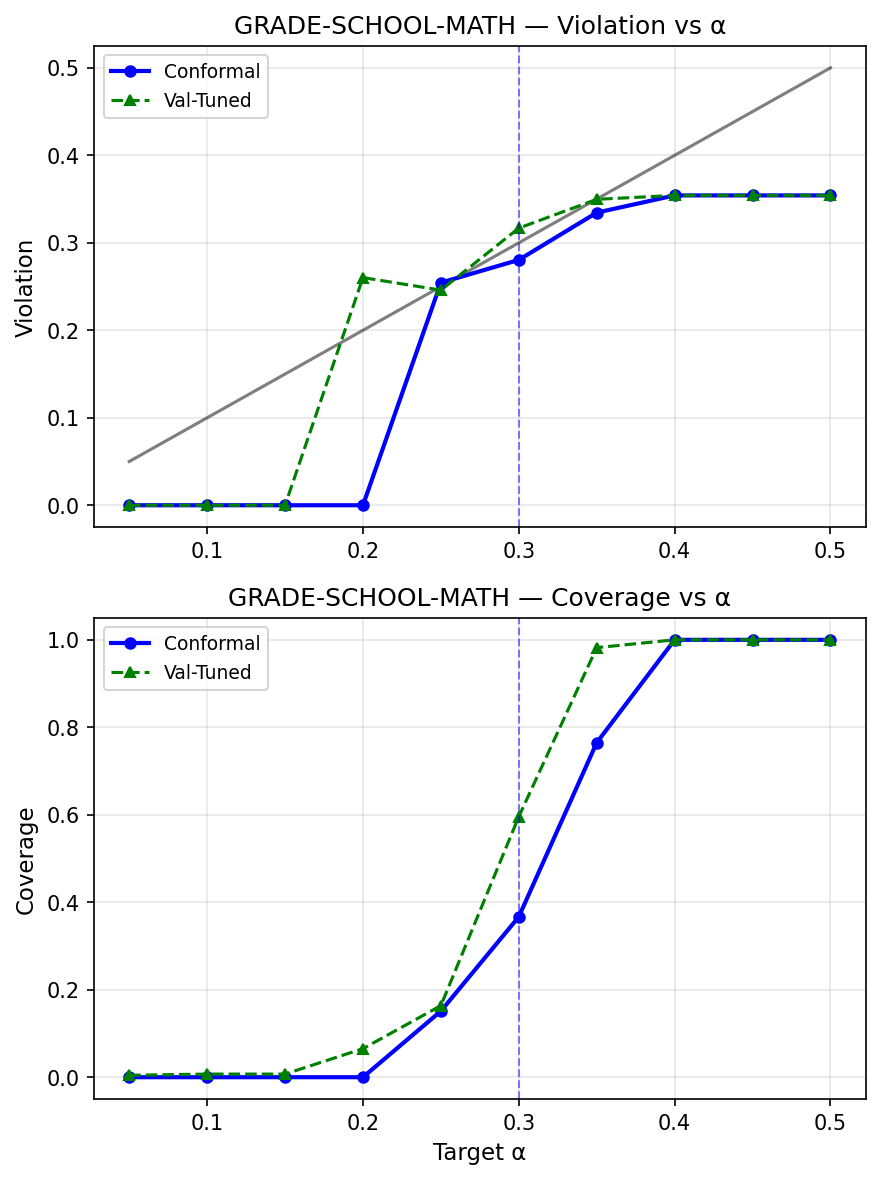

Saved: fig_alpha_sweep_full_grade-school-math.pdf


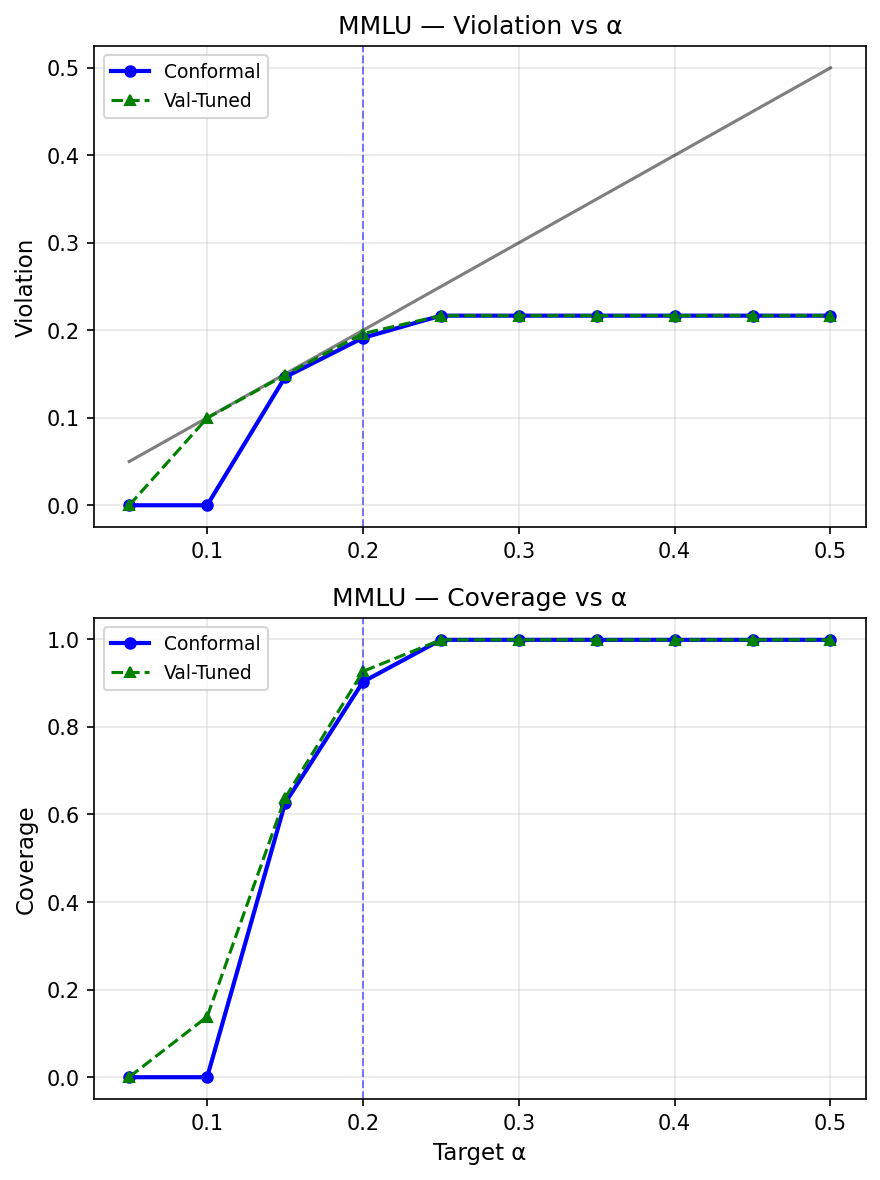

Saved: fig_alpha_sweep_full_mmlu.pdf


In [ ]:
for ds_name in active_ds:
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))
    g = gates[ds_name]
    alpha_ds = ALPHA_PER_DS[ds_name]
    Y_cal  = splits_per_dataset[ds_name]['Y_cal']
    Y_val  = splits_per_dataset[ds_name]['Y_val']
    Y_test = splits_per_dataset[ds_name]['Y_test']

    conf_v, conf_c = [], []
    vt_v, vt_c = [], []

    for a in alpha_values:
        t_conf, _ = find_conformal_threshold(g['cal_scores'], Y_cal, a, DELTA)
        res = evaluate_routing(g['test_scores'], Y_test, t_conf, a)
        conf_v.append(res['violation']); conf_c.append(res['coverage'])

        t_val, _ = find_val_tuned_threshold(g['val_scores'], Y_val, a)
        res = evaluate_routing(g['test_scores'], Y_test, t_val, a)
        vt_v.append(res['violation']); vt_c.append(res['coverage'])

    # Top: violation
    ax = axes[0]
    ax.plot(alpha_values, alpha_values, 'k-', lw=1.5, alpha=0.5)
    ax.plot(alpha_values, conf_v, 'b-o', ms=5, lw=2, label='Conformal')
    ax.plot(alpha_values, vt_v, 'g--^', ms=5, lw=1.5, label='Val-Tuned')
    ax.axvline(x=alpha_ds, color='blue', ls='--', lw=1, alpha=0.5)
    ax.set_ylabel('Violation')
    ax.set_title(f'{ds_name.upper()} — Violation vs α')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # Bottom: coverage
    ax = axes[1]
    ax.plot(alpha_values, conf_c, 'b-o', ms=5, lw=2, label='Conformal')
    ax.plot(alpha_values, vt_c, 'g--^', ms=5, lw=1.5, label='Val-Tuned')
    ax.axvline(x=alpha_ds, color='blue', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('Target α'); ax.set_ylabel('Coverage')
    ax.set_title(f'{ds_name.upper()} — Coverage vs α')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f'fig_alpha_sweep_full_{ds_name}.pdf'
    plt.savefig(fname)
    plt.show()
    print(f'Saved: {fname}')

## Cell 14 — Coverage vs Violation Tradeoff Plot

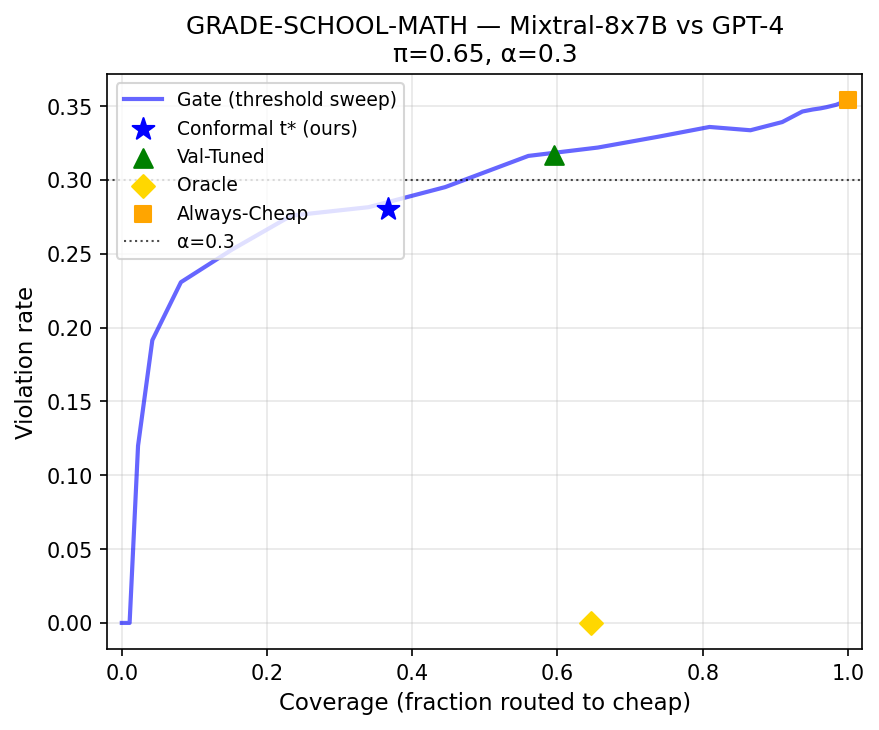

Saved: fig_coverage_vs_violation_grade-school-math.pdf


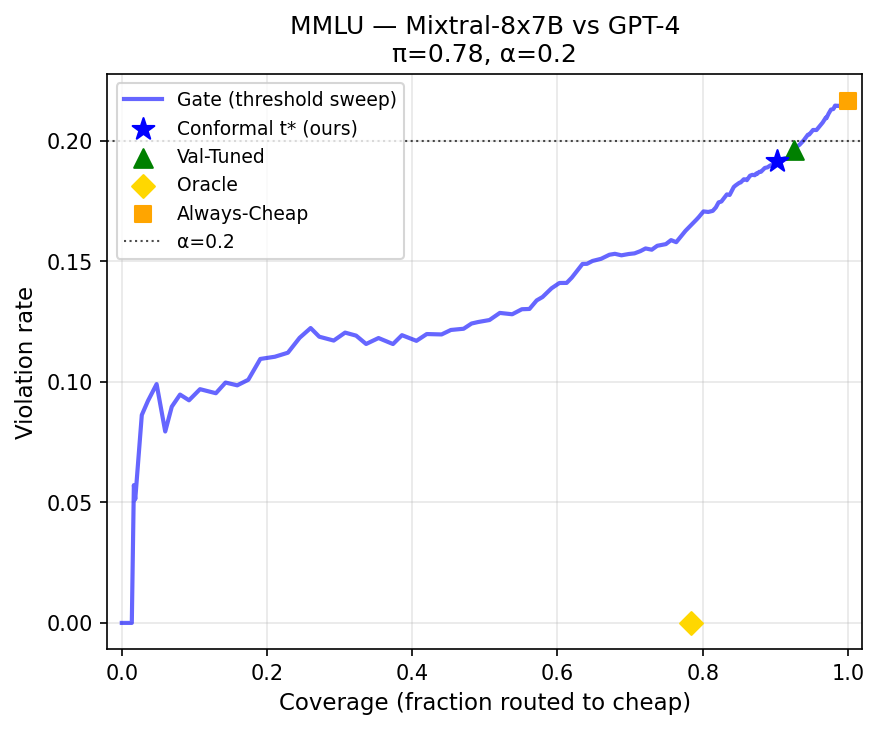

Saved: fig_coverage_vs_violation_mmlu.pdf


In [ ]:
for ds_name in active_ds:
    fig, ax = plt.subplots(figsize=(6, 5))
    g = gates[ds_name]
    alpha_ds = ALPHA_PER_DS[ds_name]
    Y_test = splits_per_dataset[ds_name]['Y_test']

    gate_cov, gate_viol = [], []
    for t in np.linspace(0, 1, 300):
        res = evaluate_routing(g['test_scores'], Y_test, t, alpha_ds)
        gate_cov.append(res['coverage']); gate_viol.append(res['violation'])

    ax.plot(gate_cov, gate_viol, 'b-', lw=2, alpha=0.6, label='Gate (threshold sweep)')

    cr = conformal_results[ds_name]['test_result']
    ax.scatter([cr['coverage']], [cr['violation']], c='blue', s=120, marker='*',
               zorder=10, label=f'Conformal t* (ours)')

    vt = val_tuned_results[ds_name]['test_result']
    ax.scatter([vt['coverage']], [vt['violation']], c='green', s=80, marker='^',
               zorder=9, label=f'Val-Tuned')

    bl = baseline_results[ds_name]
    ax.scatter([bl['Oracle']['coverage']], [0], c='gold', s=60, marker='D', zorder=8, label='Oracle')
    ax.scatter([1.0], [bl['Always-Cheap']['violation']], c='orange', s=60, marker='s', zorder=8, label='Always-Cheap')

    ax.axhline(y=alpha_ds, color='k', ls=':', lw=1, alpha=0.7, label=f'α={alpha_ds}')
    ax.set_xlabel('Coverage (fraction routed to cheap)')
    ax.set_ylabel('Violation rate')
    ax.set_title(f'{ds_name.upper()} — {CHEAP_NAME} vs {EXPENSIVE_NAME}\nπ={g["pi"]:.2f}, α={alpha_ds}')
    ax.set_xlim(-0.02, 1.02)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f'fig_coverage_vs_violation_{ds_name}.pdf'
    plt.savefig(fname)
    plt.show()
    print(f'Saved: {fname}')

## Cell 15 — Cost Analysis

In [ ]:
print(f'Cost model: cheap=${COST_CHEAP:.6f}, expensive=${COST_EXPENSIVE:.6f}, gate=${COST_GATE}')
print(f'Cost ratio: {COST_EXPENSIVE/max(COST_CHEAP, 1e-10):.1f}x\n')

for ds_name in DATASETS:
    if ds_name not in conformal_results: continue
    alpha_ds = ALPHA_PER_DS[ds_name]
    cr = conformal_results[ds_name]['test_result']
    vt = val_tuned_results[ds_name]['test_result']
    bl = baseline_results[ds_name]

    print(f'=== {ds_name.upper()} (α={alpha_ds}) ===')
    methods = [
        ('Conformal (ours)',  cr['coverage'], cr['violation']),
        ('Val-Tuned',         vt['coverage'], vt['violation']),
        ('Always-Expensive',  0.0, 0.0),
        ('Always-Cheap',      1.0, bl['Always-Cheap']['violation']),
    ]
    for name, cov, viol in methods:
        cost = compute_cost(cov)
        savings = (1 - cost / COST_EXPENSIVE) * 100
        holds = "✓" if viol <= alpha_ds else "✗"
        print(f'  {name:25s} cost=${cost:.6f} savings={savings:5.1f}% cov={cov:.3f} viol={viol:.3f} {holds}')
    print()

Cost model: cheap=$0.000135, expensive=$0.003293, gate=$0.0
Cost ratio: 24.5x

=== GRADE-SCHOOL-MATH (α=0.3) ===
  Conformal (ours)          cost=$0.002135 savings= 35.2% cov=0.367 viol=0.280 ✓
  Val-Tuned                 cost=$0.001411 savings= 57.1% cov=0.596 viol=0.317 ✗
  Always-Expensive          cost=$0.003293 savings=  0.0% cov=0.000 viol=0.000 ✓
  Always-Cheap              cost=$0.000135 savings= 95.9% cov=1.000 viol=0.354 ✗

=== MMLU (α=0.2) ===
  Conformal (ours)          cost=$0.000442 savings= 86.6% cov=0.903 viol=0.191 ✓
  Val-Tuned                 cost=$0.000367 savings= 88.9% cov=0.926 viol=0.196 ✓
  Always-Expensive          cost=$0.003293 savings=  0.0% cov=0.000 viol=0.000 ✓
  Always-Cheap              cost=$0.000135 savings= 95.9% cov=1.000 viol=0.216 ✗



## Cell 16 — Feasibility Landscape

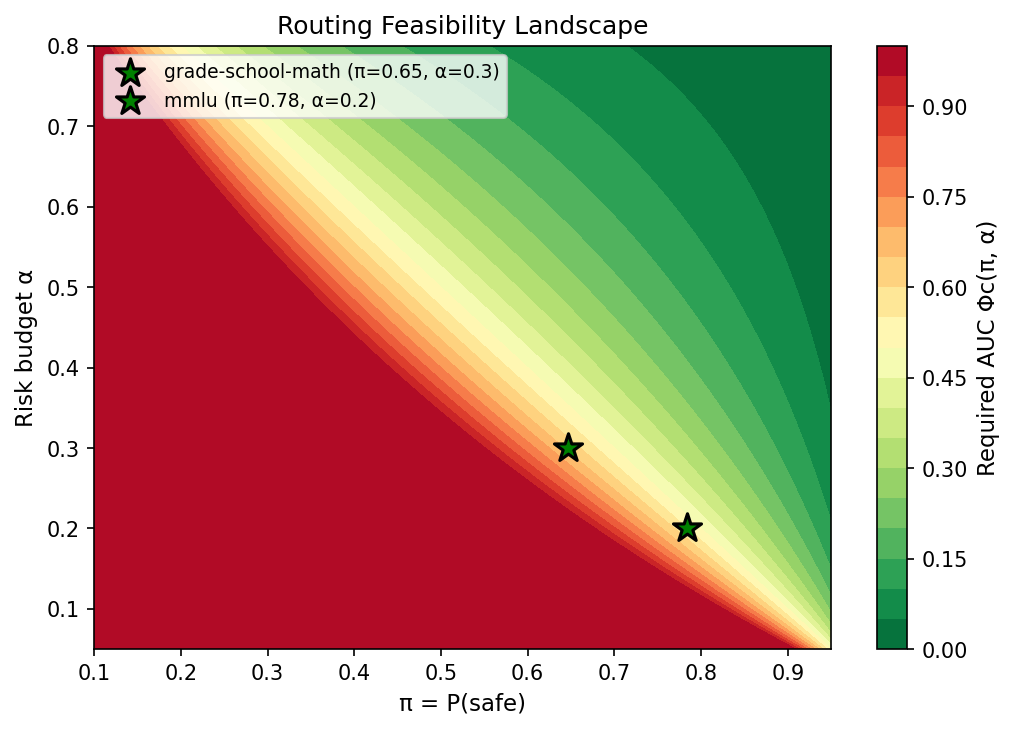

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
pi_range = np.linspace(0.1, 0.95, 200)
alpha_range = np.linspace(0.05, 0.80, 200)
PI, AL = np.meshgrid(pi_range, alpha_range)
PHI_C = np.vectorize(lambda p, a: compute_feasibility(p, a)[1])(PI, AL)
im = ax.contourf(PI, AL, PHI_C, levels=20, cmap='RdYlGn_r')
plt.colorbar(im, ax=ax, label='Required AUC Φc(π, α)')
for ds_name in active_ds:
    g = gates[ds_name]
    alpha_ds = ALPHA_PER_DS[ds_name]
    feasible = conformal_results[ds_name]['cal_info']['feasible']
    ax.scatter([g['pi']], [alpha_ds], c='green' if feasible else 'red', s=200,
              marker='*' if feasible else 'X', edgecolors='black', lw=1.5, zorder=10,
              label=f'{ds_name} (π={g["pi"]:.2f}, α={alpha_ds})')
ax.set_xlabel('π = P(safe)')
ax.set_ylabel('Risk budget α')
ax.set_title('Routing Feasibility Landscape')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('fig_feasibility.pdf')
plt.show()

## Cell 17 — ROC Curves with Feasibility Line

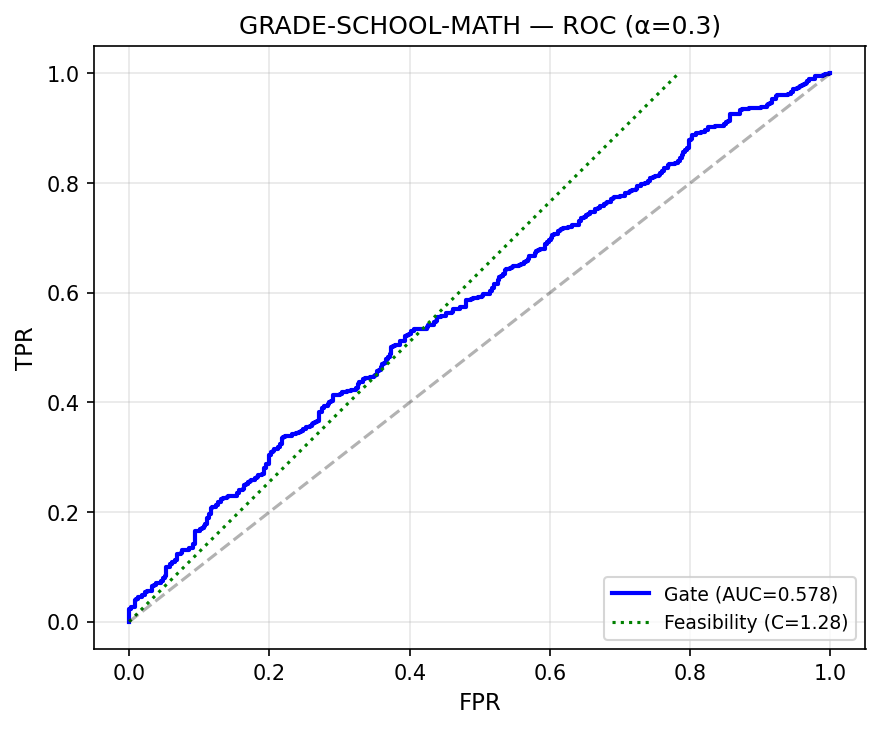

Saved: fig_roc_grade-school-math.pdf


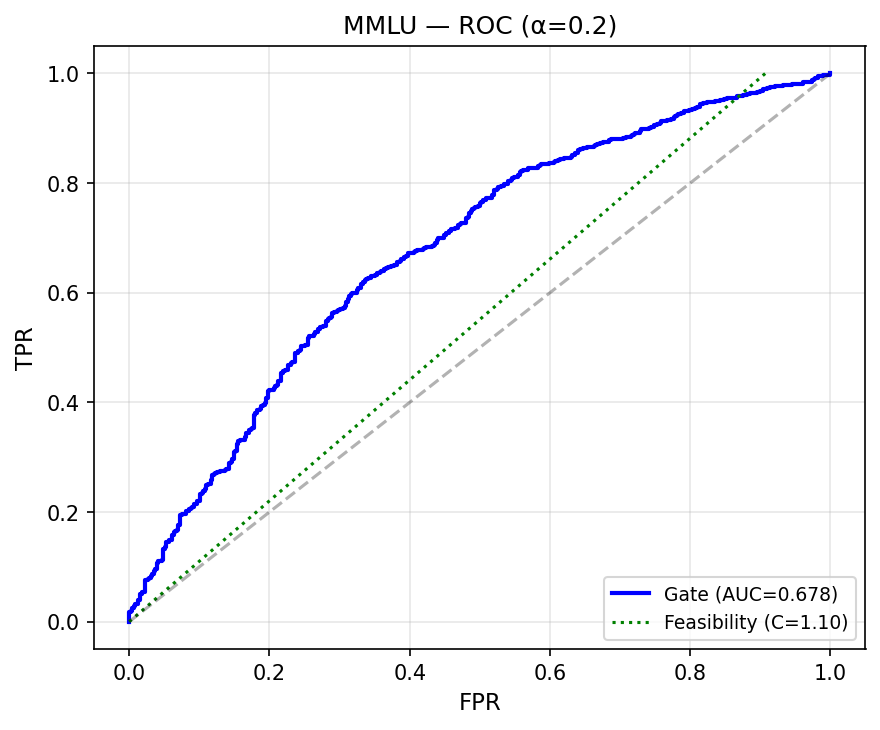

Saved: fig_roc_mmlu.pdf


In [ ]:
for ds_name in active_ds:
    fig, ax = plt.subplots(figsize=(6, 5))
    g = gates[ds_name]
    Y_test = splits_per_dataset[ds_name]['Y_test']
    fpr, tpr, _ = roc_curve(Y_test, g['test_scores'])
    ax.plot(fpr, tpr, 'b-', lw=2, label=f'Gate (AUC={g["auc_test"]:.3f})')
    C = g['C']
    if C < 20:
        fl = np.linspace(0, min(1, 1/C), 100)
        ax.plot(fl, C * fl, 'g:', lw=1.5, label=f'Feasibility (C={C:.2f})')
    ax.plot([0,1],[0,1],'k--',alpha=0.3)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'{ds_name.upper()} — ROC (α={ALPHA_PER_DS[ds_name]})')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f'fig_roc_{ds_name}.pdf'
    plt.savefig(fname)
    plt.show()
    print(f'Saved: {fname}')

## Cell 18 — LaTeX Table for Paper

In [ ]:
print(r'\begin{table}[t]')
print(r'\centering\small')
print(r'\caption{Routing results on RouterBench. $\delta=' + str(DELTA) + r'$.}')
print(r'\label{tab:results}')
print(r'\begin{tabular}{llccc}')
print(r'\toprule')
print(r'Dataset & Method & Cov. & Viol. & $\leq\alpha$? \\')
print(r'\midrule')

for ds_name in active_ds:
    g = gates[ds_name]
    alpha_ds = ALPHA_PER_DS[ds_name]
    cr = conformal_results[ds_name]['test_result']
    vt = val_tuned_results[ds_name]['test_result']
    bl = baseline_results[ds_name]

    rows = [
        ('Conformal (ours)', cr['coverage'], cr['violation'], cr['guarantee_holds']),
        ('Val-Tuned',        vt['coverage'], vt['violation'], vt['violation'] <= alpha_ds),
        ('Naive ($t$=0.5)',  bl['Naive (t=0.5)']['coverage'], bl['Naive (t=0.5)']['violation'], bl['Naive (t=0.5)']['violation'] <= alpha_ds),
        ('Oracle',           bl['Oracle']['coverage'], 0.0, True),
    ]
    for i, (name, cov, viol, holds) in enumerate(rows):
        prefix = f'{ds_name.upper()} ($\\pi$={g["pi"]:.2f}, $\\alpha$={alpha_ds})' if i == 0 else ''
        check = r'\cmark' if holds else r'\xmark'
        print(f'{prefix} & {name} & {cov:.3f} & {viol:.3f} & {check} \\\\')
    print(r'\midrule')

print(r'\bottomrule')
print(r'\end{tabular}')
print(r'\end{table}')

\begin{table}[t]
\centering\small
\caption{Routing results on RouterBench. $\delta=0.1$.}
\label{tab:results}
\begin{tabular}{llccc}
\toprule
Dataset & Method & Cov. & Viol. & $\leq\alpha$? \\
\midrule
GRADE-SCHOOL-MATH ($\pi$=0.65, $\alpha$=0.3) & Conformal (ours) & 0.367 & 0.280 & \cmark \\
 & Val-Tuned & 0.596 & 0.317 & \xmark \\
 & Naive ($t$=0.5) & 1.000 & 0.354 & \xmark \\
 & Oracle & 0.646 & 0.000 & \cmark \\
\midrule
MMLU ($\pi$=0.78, $\alpha$=0.2) & Conformal (ours) & 0.903 & 0.191 & \cmark \\
 & Val-Tuned & 0.926 & 0.196 & \cmark \\
 & Naive ($t$=0.5) & 0.993 & 0.215 & \xmark \\
 & Oracle & 0.784 & 0.000 & \cmark \\
\midrule
\bottomrule
\end{tabular}
\end{table}


## Cell 19 — LaTeX Feasibility Overview Table

In [ ]:
# ============================================================
# Cell 19 — LaTeX Feasibility Overview Table (per dataset)
# ============================================================

print(r'\begin{table}[t]')
print(r'\centering\small')
print(r'\caption{Feasibility overview: cheap models vs GPT-4 on RouterBench, per dataset.}')
print(r'\label{tab:feasibility}')
print(r'\begin{tabular}{llcccc}')
print(r'\toprule')
print(r'Cheap Model & Dataset & $\alpha$ & $\pi$ & $C(\pi,\alpha)$ & $\Phi^*_c$ \\')
print(r'\midrule')

for ds_name in DATASETS:
    ds_rows = [r for r in feasibility_rows if r['dataset'] == ds_name]
    for row in sorted(ds_rows, key=lambda r: r['pi']):
        print(f'{row["short_name"]} & {ds_name} & {row["alpha"]:.2f} & {row["pi"]:.3f} & {row["C"]:.2f} & {row["phi_c_star"]:.3f} \\\\')
    print(r'\midrule')

print(r'\bottomrule')
print(r'\end{tabular}')
print(r'\end{table}')

\begin{table}[t]
\centering\small
\caption{Feasibility overview: cheap models vs GPT-4 on RouterBench, per dataset.}
\label{tab:feasibility}
\begin{tabular}{llcccc}
\toprule
Cheap Model & Dataset & $\alpha$ & $\pi$ & $C(\pi,\alpha)$ & $\Phi^*_c$ \\
\midrule
mistral-7b-chat & grade-school-math & 0.30 & 0.408 & 3.39 & 0.852 \\
code-llama-instruct-34b-chat & grade-school-math & 0.30 & 0.514 & 2.21 & 0.774 \\
WizardLM-13B-V1.2 & grade-school-math & 0.30 & 0.635 & 1.34 & 0.627 \\
mixtral-8x7b-chat & grade-school-math & 0.30 & 0.646 & 1.28 & 0.609 \\
llama-2-70b-chat & grade-school-math & 0.30 & 0.660 & 1.20 & 0.584 \\
Yi-34B-Chat & grade-school-math & 0.30 & 0.713 & 0.94 & 0.500 \\
claude-instant-v1 & grade-school-math & 0.30 & 0.836 & 0.46 & 0.500 \\
gpt-3.5-turbo-1106 & grade-school-math & 0.30 & 0.854 & 0.40 & 0.500 \\
claude-v1 & grade-school-math & 0.30 & 0.895 & 0.27 & 0.500 \\
claude-v2 & grade-school-math & 0.30 & 0.931 & 0.17 & 0.500 \\
\midrule
code-llama-instruct-34b-chat & mmlu 

---
## Summary of Figures

1. **`fig_alpha_sweep.pdf`** — KEY FIGURE: Guarantee reliability across α values
2. **`fig_alpha_sweep_full.pdf`** — α-sweep with both violation and coverage
3. **`fig_coverage_vs_violation.pdf`** — Coverage-violation tradeoff curve
4. **`fig_feasibility.pdf`** — Feasibility landscape
5. **`fig_roc_curves.pdf`** — Diagnostic ROC curves